Load the Dataset and Explore

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
iris = load_iris()
X = iris.data          # feature matrix
y = iris.target        # target vector
feature_names = iris.feature_names
target_names = iris.target_names

print("Feature names:", feature_names)
print("Target names:", target_names)
print("Data shape:", X.shape)
print("Target distribution:", np.bincount(y))

# Convert to DataFrame for easy exploration
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species'] = df['species'].map({i: name for i, name in enumerate(target_names)})
print(df.head())
print(df.describe())

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
Target distribution: [50 50 50]
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.76

Split into Training and Testing Sets

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 105
Test set size: 45


Feature Scaling (Important for Logistic Regression)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train a Logistic Regression Model

In [4]:
logreg = LogisticRegression(multi_class='ovr', max_iter=200, random_state=42)
logreg.fit(X_train_scaled, y_train)

c:\Users\Mg\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='ovr', random_state=42)

Make Predictions and Evaluate

Logistic Regression Evaluation:
Accuracy : 0.8444
Precision: 0.8452
Recall   : 0.8444
F1-Score : 0.8443


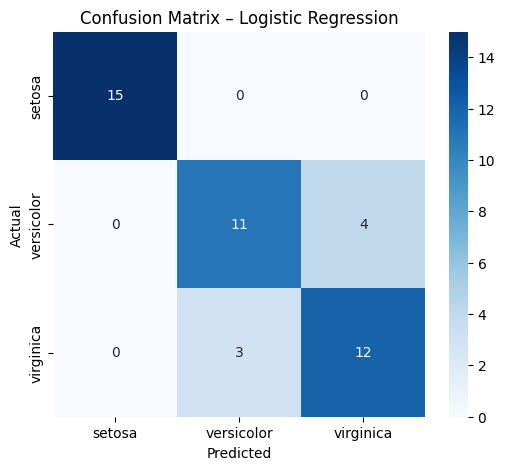

In [5]:
y_pred = logreg.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Logistic Regression Evaluation:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix – Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Sample Predictions with Actual Values

In [6]:
sample_indices = [0, 5, 10, 15, 20]  # first few test samples
print("\nSample Predictions (Logistic Regression):")
for i in sample_indices:
    if i < len(X_test):
        pred = logreg.predict(X_test_scaled[i].reshape(1, -1))[0]
        actual = y_test[i]
        print(f"Sample {i}: Predicted = {target_names[pred]}, Actual = {target_names[actual]}")


Sample Predictions (Logistic Regression):
Sample 0: Predicted = virginica, Actual = virginica
Sample 5: Predicted = virginica, Actual = virginica
Sample 10: Predicted = setosa, Actual = setosa
Sample 15: Predicted = virginica, Actual = virginica
Sample 20: Predicted = versicolor, Actual = versicolor


Bonus: Train a Decision Tree and Compare

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)   # no scaling needed
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Accuracy: {acc_dt:.4f}")

# Compare with Logistic Regression
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_dt, target_names=target_names))


Decision Tree Accuracy: 0.9333
Logistic Regression Accuracy: 0.8444

Logistic Regression Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      0.73      0.76        15
   virginica       0.75      0.80      0.77        15

    accuracy                           0.84        45
   macro avg       0.85      0.84      0.84        45
weighted avg       0.85      0.84      0.84        45


Decision Tree Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45

